# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [2]:
STUDENT_NAME = "Phạm Trường Quốc Huy"  
STUDENT_ID = "25122071"    

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Phạm Trường Quốc Huy (25122071)


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: D:\HCMUS\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [5]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [8]:
# TODO N1
# shifted_logits = ...
# exp_logits = ...
# class_probabilities = ...
# predicted_classes = ...
# confidence_scores = ...

shifted_logits = logits - np.max(logits, axis = 1, keepdims=True)

exp_logits = np.exp(shifted_logits)

class_probabilities = exp_logits/np.sum(exp_logits, axis = 1, keepdims=True)

predicted_classes = np.argmax(class_probabilities, axis=1)

confidence_scores = np.max(class_probabilities, axis=1)  

In [9]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [10]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [12]:
# TODO N2
# train_feature_mean = ...
# train_feature_std = ...
# X_train_scaled = ...
# X_val_scaled = ...

train_feature_mean = np.mean(X_train, axis=0)
train_feature_std = np.std(X_train, axis=0)
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std


In [13]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [15]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [16]:
# TODO N3
# correct_mask = ...
# high_confidence_mask = ...
# review_mask = ...
# review_indices = ...

correct_mask = (predicted_classes == true_labels)
high_confidence_mask = (confidence_scores >= confidence_threshold)
review_mask = (~correct_mask) | (~high_confidence_mask)
review_indices = np.where(review_mask)[0]



## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [18]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [19]:
# TODO N4
# normalized_batch = ...
# augmented_batch = ...
# augmented_batch[0, 0, 0, 0] = ...

normalized_batch = image_batch_uint8.astype(np.float32) / 255.0

augmented_batch = np.flip(normalized_batch, axis=2).copy()

augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->

1. Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports.
2. Giá trị thiếu trong `automobile_raw.csv` được giữ dưới dạng ký hiệu `?`.
3. `symboling` cho biết Mức đánh giá rủi ro bảo hiểm

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [21]:
# TODO D1
# raw_df = ...
# raw_shape = ...
# raw_missing_marker_count = ...

raw_df = pd.read_csv(r"D:\HCMUS\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv")
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == '?').sum().sum()



## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [23]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [24]:
# TODO D2
# df_clean = ...
# for column in NUMERIC_COLUMNS:
#     ...
# missing_by_column = ...

df_clean = raw_df.replace('?', np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])

missing_by_column = df_clean.isna().sum()

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->
3. Vì Các cột mang ý nghĩa và đơn vị hoàn toàn khác nhau (ví dụ: wheel_base là chiều dài trục tính bằng inch/cm, engine_size là thể tích động cơ, peak_rpm là vòng tua máy lên tới hàng ngàn). -> nếu fill cùng một giá trị thì sẽ không phù hợp, làm sai lệch tương quan giữa các đặc trưng với nhau, khiến mô hình học ra những quy luật sai lệch

4. Nên Drop. Trong bài này, `price` đóng vai trò là nhãn mục tiêu mà mô hình muốn dự đoán. Nếu ta tự bịa ra nhãn thì sẽ khiến các đánh giá về mô hinh trở nên sai lệch và vô nghĩa

5. Nếu tỉ lệ missing quá cao, việc dùng các kĩ thuật như fill sẽ không còn quá nhiều giá trị. Ngược lại nếu ta drop mẫu -> dẫn đến thiếu dữ liệu huấn luyện, nếu ta drop cột  -> có thể dẫn đến mất chỉ báo quan trọng. 

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [25]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [27]:
# TODO D3
# analysis_df = ...
# X_auto = ...
# auto_feature_mean = ...
# auto_feature_std = ...
# X_auto_scaled = ...

analysis_df = df_clean[AUTO_FEATURES].dropna()
X_auto = analysis_df.to_numpy(dtype=np.float64)
auto_feature_mean = np.mean(X_auto, axis=1, keepdims=True)
auto_feature_std = np.std(X_auto, axis=1, keepdims=True)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [30]:
# TODO D4
# price_index = ...
# price_z = ...
# price_outlier_mask = ...
# price_outliers = ...

price_index = AUTO_FEATURES.index('price')
price_z = X_auto_scaled[:, price_index]
price_outlier_mask = np.abs(price_z) > 2
price_outliers = X_auto[price_outlier_mask]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [31]:
# TODO D5
# engine_price_corr = ...
# price_by_body_style = ...

valid_data = df_clean[['engine_size', 'price']].dropna()
engine_array = valid_data['engine_size'].to_numpy()
price_array = valid_data['price'].to_numpy()

engine_price_corr = np.corrcoef(engine_array, price_array)[0, 1]

price_by_body_style = df_clean.groupby('body_style')['price'].mean().sort_index()

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

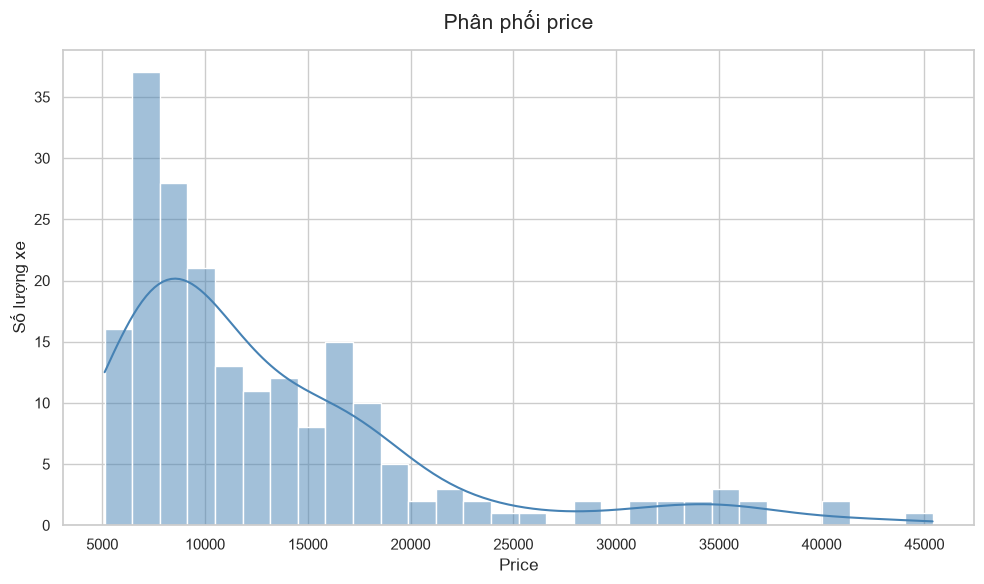

In [36]:
# TODO M2.1: histogram/KDE của price

plt.figure(figsize=(10, 6))

sns.histplot(data=df_clean, x='price', kde=True, bins=30, color='steelblue')

plt.title("Phân phối price", fontsize=15, pad=15)
plt.xlabel("Price", fontsize=12)
plt.ylabel("Số lượng xe", fontsize=12)

plt.tight_layout()
plt.show()

**Nhận xét:** 
Phân phối giá xe có dạng lệch phải (right-skewed), với phần lớn các mẫu xe tập trung đông đúc ở phân khúc giá bình dân đến tầm trung (dưới 15,000 USD). Càng tiến về phân khúc cao cấp (trên 30,000 USD), số lượng xe càng giảm mạnh, tạo thành một phần đuôi dài kéo dài về phía bên phải của biểu đồ.

## M2.2 Dataset có cân bằng theo body style không?

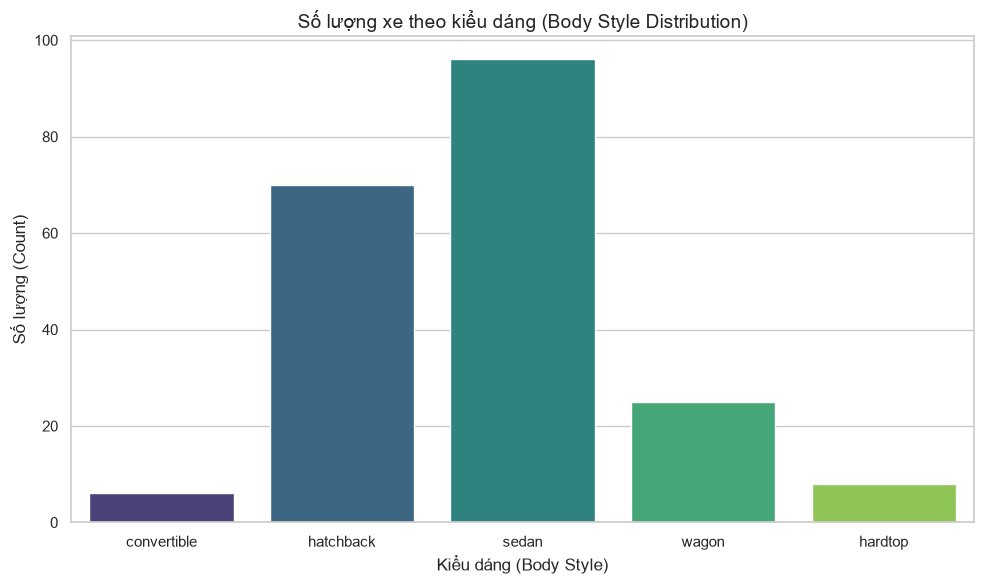

In [43]:
# TODO M2.2: countplot của body_style

plt.figure(figsize=(10, 6))

sns.countplot(data=df_clean, x='body_style', hue= 'body_style', palette='viridis', legend=False)

plt.title('Số lượng xe theo kiểu dáng (Body Style Distribution)', fontsize=14)
plt.xlabel('Kiểu dáng (Body Style)', fontsize=12)
plt.ylabel('Số lượng (Count)', fontsize=12)

plt.tight_layout()
plt.show()

**Nhận xét:** Dataset mất cân bằng nghiêm trọng (imbalanced). Các dòng xe phổ thông như sedan và hatchback chiếm đại đa số áp đảo, trong khi các dòng xe thể thao/đặc thù như convertible và hardtop có số lượng mẫu rất ít. Điều này có thể khiến mô hình ML sau này học kém hơn trên các dòng xe hiếm.

## M2.3 Price khác nhau theo body style ra sao?

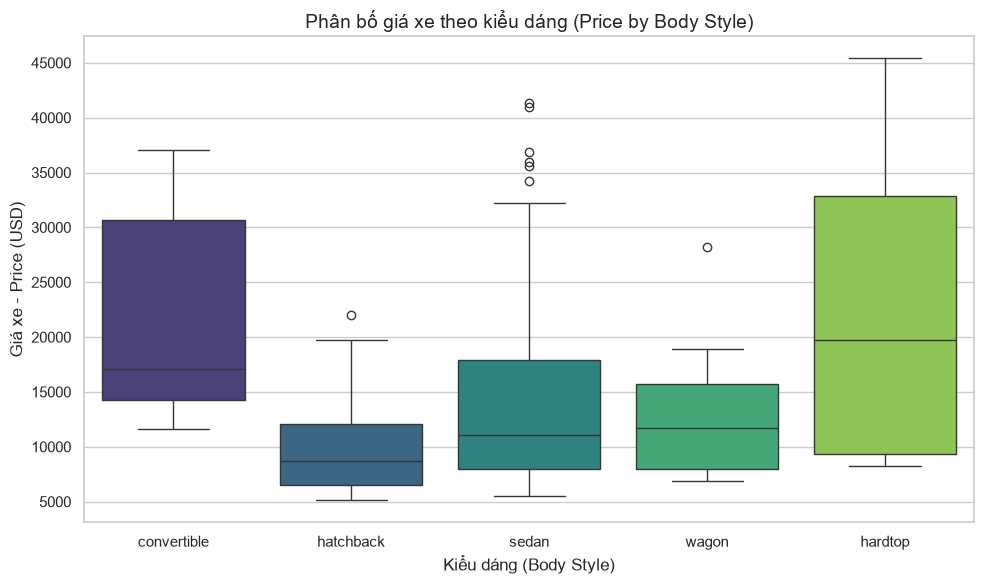

In [42]:
# TODO M2.3: boxplot price theo body_style

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.boxplot(data=df_clean, x='body_style', y='price', hue= 'body_style', palette='viridis', legend=False)

plt.title('Phân bố giá xe theo kiểu dáng (Price by Body Style)', fontsize=14)
plt.xlabel('Kiểu dáng (Body Style)', fontsize=12)
plt.ylabel('Giá xe - Price (USD)', fontsize=12)

plt.tight_layout()
plt.show()

**Nhận xét:** Mức giá có sự phân hóa rõ rệt theo kiểu dáng. hatchback tập trung chủ yếu ở phân khúc giá rẻ với biên độ hẹp. Ngược lại, hardtop và convertible có giá trung vị (median) cao nhất, định vị ở phân khúc đắt tiền. Riêng sedan có dải giá phân bố cực kỳ rộng và xuất hiện nhiều điểm dị biệt (outliers) vọt lên mức giá rất cao.

## M2.4 Engine size liên quan thế nào tới price?

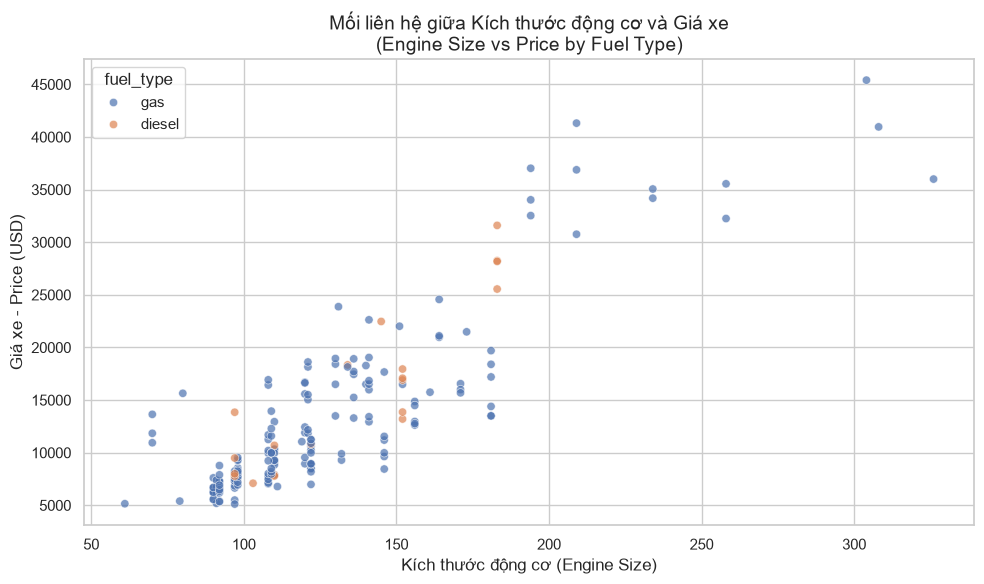

In [44]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type

plt.figure(figsize=(10, 6))

# Vẽ Scatterplot, thêm alpha để các điểm trong suốt dễ nhìn khi đè lên nhau
sns.scatterplot(data=df_clean, x='engine_size', y='price', hue='fuel_type', alpha=0.7)

plt.title('Mối liên hệ giữa Kích thước động cơ và Giá xe\n(Engine Size vs Price by Fuel Type)', fontsize=14)
plt.xlabel('Kích thước động cơ (Engine Size)', fontsize=12)
plt.ylabel('Giá xe - Price (USD)', fontsize=12)

plt.tight_layout()
plt.show()

**Nhận xét:** Có sự tương quan thuận rất mạnh (positive correlation): Kích thước động cơ càng lớn thì giá xe càng cao. Xe chạy xăng (gas) trải dài trên toàn bộ phổ dữ liệu và đạt đến những mức giá đắt nhất, trong khi xe chạy dầu (diesel) chủ yếu cụm lại ở dải động cơ và mức giá tầm trung/thấp.

## M2.5 Các feature numeric tương quan ra sao?

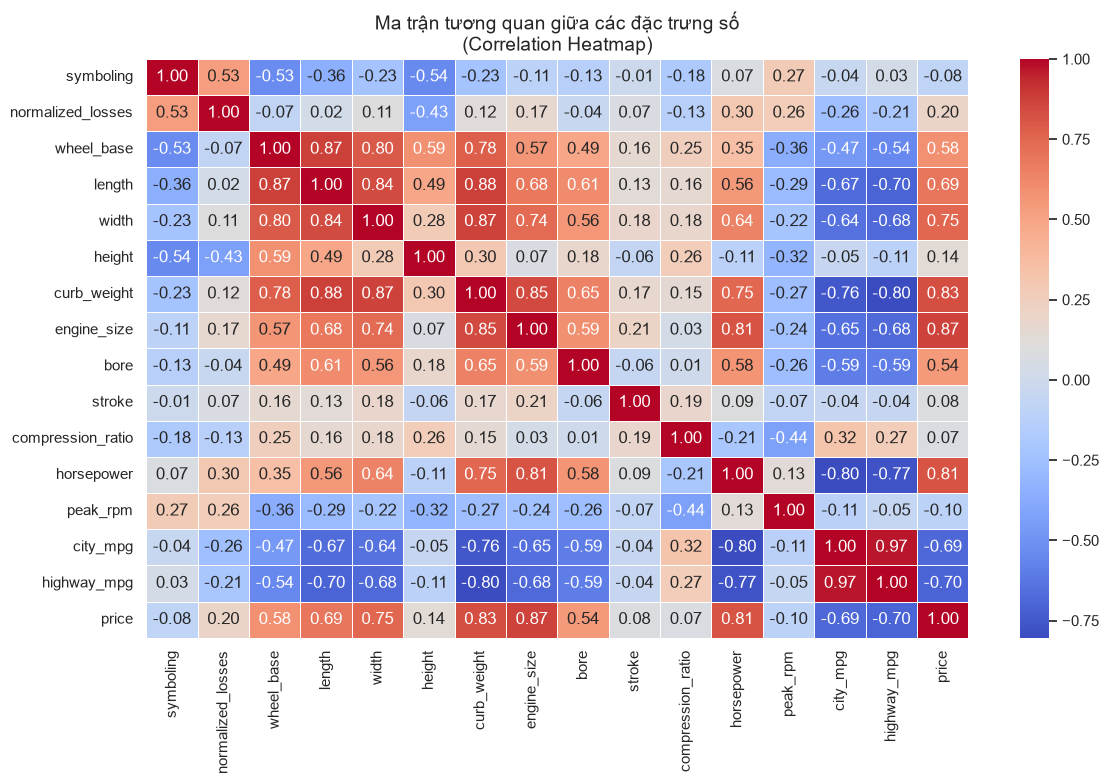

In [45]:
# TODO M2.5: correlation heatmap

plt.figure(figsize=(12, 8))

numeric_df = df_clean.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Ma trận tương quan giữa các đặc trưng số\n(Correlation Heatmap)', fontsize=14)

plt.tight_layout()
plt.show()

**Nhận xét:** Giá xe (price) có tương quan thuận rất mạnh với engine_size, curb_weight, và horsepower (các chỉ số $> 0.8$). Ngược lại, giá xe có tương quan nghịch cực kỳ rõ ràng với mức độ tiết kiệm nhiên liệu (city_mpg, highway_mpg), chứng tỏ xe càng to, nặng, đắt tiền thì càng "ngốn" xăng.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

Câu hỏi: Hệ dẫn động (drive_wheels) ảnh hưởng tới mức giá trung bình như thế nào?

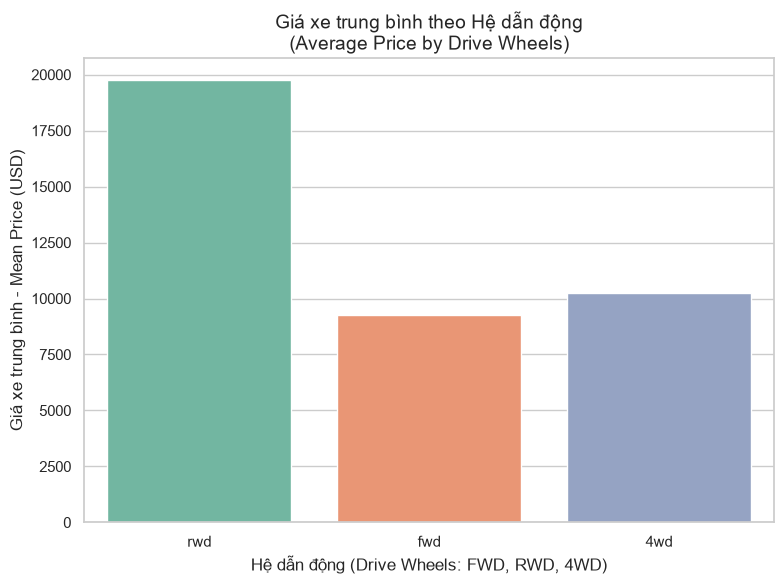

In [46]:
# TODO M2.6: biểu đồ tự chọn

plt.figure(figsize=(8, 6))

# Câu hỏi: Giá xe trung bình thay đổi thế nào theo hệ dẫn động (drive-wheels)?
sns.barplot(data=df_clean, x='drive_wheels', y='price', 
            hue='drive_wheels', legend=False, palette='Set2', errorbar=None)

plt.title('Giá xe trung bình theo Hệ dẫn động\n(Average Price by Drive Wheels)', fontsize=14)
plt.xlabel('Hệ dẫn động (Drive Wheels: FWD, RWD, 4WD)', fontsize=12)
plt.ylabel('Giá xe trung bình - Mean Price (USD)', fontsize=12)

plt.tight_layout()
plt.show()

**Nhận xét:** Xe sử dụng hệ dẫn động cầu sau (rwd - rear-wheel drive) có mức giá trung bình cao vượt trội so với phần còn lại, do hệ thống này thường được trang bị trên các dòng xe thể thao hiệu suất cao hoặc xe sang. Xe dẫn động cầu trước (fwd - front-wheel drive) có giá trung bình rẻ nhất, phù hợp với định vị của các dòng xe đô thị/bình dân.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

1. Các phát hiện chính (Key Findings)

- Phân phối giá xe lệch phải (Right-skewed): Đa số xe tập trung dưới $15,000, có các điểm ngoại lai (outliers) vọt lên trên $40,000.

- Đặc tính vật lý tác động mạnh đến giá: price có tương quan thuận rất mạnh ($r > 0.8$) với engine_size, curb_weight, horsepower.

- Đánh đổi về nhiên liệu (Trade-off): Xe đắt và động cơ lớn có tương quan nghịch với mức tiết kiệm nhiên liệu (city_mpg, highway_mpg).

- Phân tầng giá theo cấu tạo: Xe dẫn động cầu sau (RWD) và kiểu dáng Hardtop/Convertible nằm ở phân khúc giá cao; FWD và Hatchback ở phân khúc giá rẻ.

2. Hạn chế của Dataset (Limitations)

- Mất cân bằng dữ liệu (Class Imbalance): body_style (đa số sedan/hatchback) và fuel_type (đa số gas) phân bổ quá lệch, dễ gây bias cho mô hình Machine Learning.

- Missing Values: Nhiều cột (như normalized_losses) thiếu dữ liệu nghiêm trọng, buộc phải drop, làm giảm kích thước của tập dữ liệu vốn đã nhỏ (~200 mẫu).

3. Ví dụ "Correlation không đồng nghĩa Causation"

- curb_weight (Trọng lượng) có tương quan dương với price (Giá xe). Tuy nhiên, cố tình làm xe nặng hơn không giúp xe đắt hơn (không có Causation). Nguyên nhân gốc là do các xe đắt tiền trang bị động cơ lớn (engine_size) và vật liệu cao cấp, khiến giá tăng và hệ quả là xe nặng hơn.

4. Câu hỏi nên phân tích tiếp (Future Work)

- Câu hỏi: Yếu tố thương hiệu (Make/Brand) đóng góp bao nhiêu vào giá xe (Brand Premium)?
- Lý do nên phân tích là vì: Cần bóc tách xem nếu hai chiếc xe có thông số kỹ thuật giống hệt nhau, sự khác biệt về hãng sản xuất sẽ làm giá chênh lệch như thế nào.